
TFG

Este es el codigo del tfg de Borja Jimeno

In [26]:
import sys            # módulo para interactuar con el intérprete
import os             # módulo para operaciones del sistema de archivos

import numpy as np
import math as m
import matplotlib.pyplot as plt
from scipy import special
from scipy.stats import norm
import re

path="/home/borja/Documents/TFG/GeneraRitmo/Libs/ANAIS"
sys.path.append(path)

from funciones_ritmo_teorico import*
from funciones_ritmo_exp import*

plt.rcParams['font.size'] = 18

In [27]:
import numpy as np


def carga_datos_hist(titulo,archivo):
    file = uproot.open(archivo)
    file.keys()
    longitud=36*4
    datos=np.zeros((2,longitud))
    
    graph = file[titulo]
    datos[0]=graph.member("fX")
    datos[1]=graph.member("fY")
    
    return datos

Datos_PY=carga_datos_hist("gA112_6y_90_1.000000_6.000000_QFtamara_PY_SI","SI_varios_corregido.root")
Datos_RA=carga_datos_hist("gA112_6y_90_1.000000_6.000000_QFtamara_RA_SI","SI_varios_corregido.root")
Datos_WI=carga_datos_hist("gA112_6y_90_1.000000_6.000000_QFtamara_WI_SI","SI_varios_corregido.root")
Datos_DM_2=carga_datos_hist("gA112_6y_90_1.000000_6.000000_QFtamara_DM_SG_SI","SI_varios_corregido.root")
Datos_DM_3=carga_datos_hist("gA112_6y_90_1.000000_6.000000_QFtamara_DMA_SI","SI_varios_corregido.root")

Datos_resk=carga_datos_hist("gA112_6y_90_1.000000_6.000000_QFtamara_DM_SG_SI;1","SI_varios_resk.root")
Datos_DM_resk1=carga_datos_hist("gA112_6y_90_1.000000_6.000000_QFtamara_DM_SG_SI;3","SI_varios_resk.root")

Datos_DM_ANOD=carga_datos_hist("gA112_6y_90_1.000000_6.000000_QFtamara_ANOD_DM_SG_SI;1","SI_varios_resk.root")
Datos_DM_ANOD_1=carga_datos_hist("gA112_6y_90_1.000000_6.000000_QFtamara_ANOD_DM_SG_SI;2","SI_varios_resk.root")

Datos_res=carga_datos_hist("gA112_6y_90_1.000000_6.000000_QFtamara_ANOD_DM_SG_SI;3","SI_varios_resolucion.root")



PY=Datos_PY[1]
DM_2=Datos_DM_2[1]
DM_3=Datos_DM_3[1]
RA=Datos_RA[1]
WI=Datos_WI[1]
Resk=Datos_resk[1]

AN=Datos_DM_ANOD[1]
AN_1=Datos_DM_ANOD_1[1]
Resk_1=Datos_DM_resk1[1]

Res=Datos_res[1]

PY_M=Datos_PY[0]
DM_2_M=Datos_DM_2[0]
DM_3_M=Datos_DM_3[0]

RA_M=Datos_RA[0]
WI_M=Datos_WI[0]

Resk_M=Datos_resk[0]

AN_m=Datos_DM_ANOD[0]
AN_1_m=Datos_DM_ANOD_1[0]
Resk_1_M=Datos_DM_resk1[0]

Res_m=Datos_res[0]




In [28]:
DAMA1=np.loadtxt("DAMA1.txt")

DAMA1_x=[]
DAMA1_y=[]

for i in range(len(DAMA1)):
    DAMA1_x.append(DAMA1[i][0])
    DAMA1_y.append(DAMA1[i][1])

DAMA2=np.loadtxt("DAMA2.txt")

DAMA2_x=[]
DAMA2_y=[]

for i in range(len(DAMA2)):
    DAMA2_x.append(DAMA2[i][0])
    DAMA2_y.append(DAMA2[i][1])


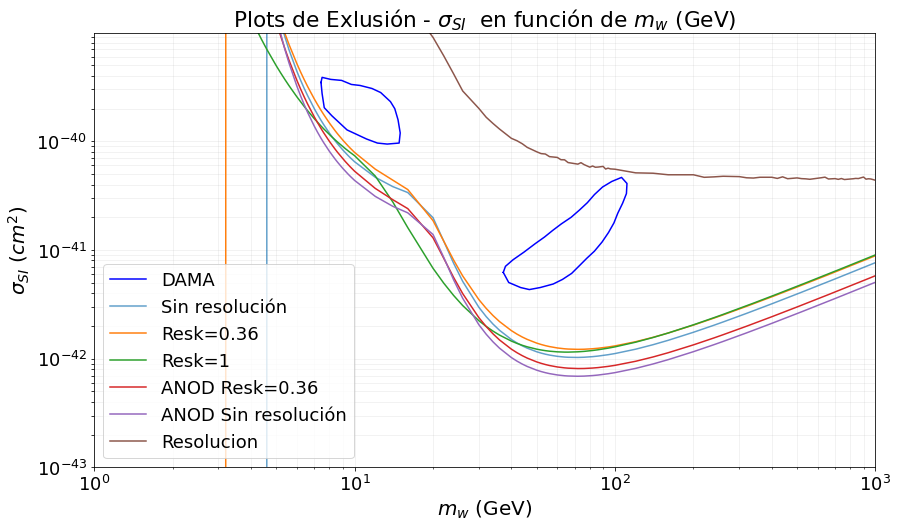

In [29]:
plt.figure(figsize=(14, 8))
ax = plt.subplot()

ax.plot(DAMA1_x,DAMA1_y,c='blue',label="DAMA")
ax.plot(DAMA2_x,DAMA2_y,c='blue')

#ax.plot(PY_M,PY, linestyle='-',label="Nuestro Código",c="black", alpha=0.8)
#ax.plot(RA_M,RA,linestyle=':',label=" RAPIDD", alpha=1)
#ax.plot(WI_M,WI, linestyle='--',label="WIMPYDD", alpha=1)


#ax.plot(DM_2_M,DM_2, linestyle='-',label="DmAnalysis (fitSimulMakeExlusion)", alpha=0.7)

ax.plot(DM_3_M,DM_3, linestyle='-',label="Sin resolución", alpha=0.7)

ax.plot(Resk_M,Resk, linestyle='-',label="Resk=0.36", alpha=1)

ax.plot(Resk_1_M,Resk_1, linestyle='-',label="Resk=1", alpha=1)

ax.plot(AN_m,AN, linestyle='-',label="ANOD Resk=0.36", alpha=1)
ax.plot(AN_1_m,AN_1, linestyle='-',label="ANOD Sin resolución", alpha=1)

ax.plot(Res_m,Res, linestyle='-',label="Resolucion", alpha=1)









ax.legend()

ax.set_title(r'Plots de Exlusión - $\sigma_{SI}$  en función de $m_w$ (GeV)')
ax.set_ylabel(r'$\sigma_{SI}$ $(cm^2)$',fontsize=20)
ax.set_xlabel(r'$m_w$ (GeV)',fontsize=20)

ax.set_yscale("log")
ax.set_xscale("log")

y_sup=1e-39
y_inf=1e-43

ax.set_ylim(y_inf,y_sup)
ax.set_xlim(1,1000)

exp_min = int(np.floor(np.log10(y_inf)))   
exp_max = int(np.ceil(np.log10(y_sup)))    
exps = np.arange(exp_min, exp_max)     


all_ticks = []
for e in exps:
    decade = (np.arange(1, 10) * (10.0**e)).tolist()
    all_ticks.extend(decade)
all_ticks = np.array(all_ticks)

ax.set_yticks(all_ticks)                    

ax.grid(which='both', linestyle='-', alpha=0.2)


In [30]:
for i in range (11):
    PY=np.delete(PY,0)
    PY_M=np.delete(PY_M,0)
    
for i in range (11):
    RA=np.delete(RA,0)
    RA_M=np.delete(RA_M,0)

for i in range (11):
    WI=np.delete(WI,0)
    WI_M=np.delete(WI_M,0)



for i in range (11):
    DM_2=np.delete(DM_2,0)
    DM_2_M=np.delete(DM_2_M,0)
    DM_3=np.delete(DM_3,0)
    DM_3_M=np.delete(DM_3_M,0)
    Resk=np.delete(Resk,0)
    Resk_M=np.delete(Resk_M,0)




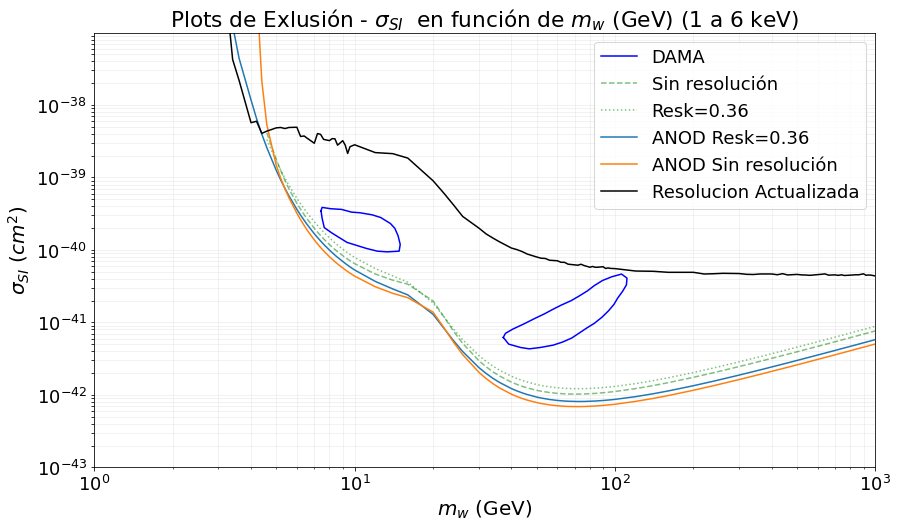

In [31]:
plt.figure(figsize=(14, 8))
ax = plt.subplot()

''' 
ax.plot(PY_M,PY, linestyle='-',label="Nuestro Código",c="black", alpha=0.8)
ax.plot(RA_M,RA,linestyle=':',label=" RAPIDD", alpha=1)
ax.plot(WI_M,WI, linestyle='--',label="WIMPYDD", alpha=1)


ax.plot(DM_2_M,DM_2, linestyle='-',label="DmAnalysis (fitSimulMakeExlusion)", alpha=0.7)
ax.plot(DM_3_M,DM_3, linestyle='-',label="DmAnalysis (dumpRate)", alpha=0.7)

ax.plot(Resk_M,Resk, linestyle='-',label="DmAnalysis (dumpRate)", alpha=1)

'''

ax.plot(DAMA1_x,DAMA1_y,c='blue',label="DAMA")
ax.plot(DAMA2_x,DAMA2_y,c='blue')


ax.plot(DM_3_M,DM_3, linestyle='--',label="Sin resolución", alpha=0.5, c="green")

ax.plot(Resk_M,Resk, linestyle=':',label="Resk=0.36", alpha=0.5, c="green")

#ax.plot(Resk_1_M,Resk_1, linestyle='--',label="Resk=1", alpha=0.5,c="green")

ax.plot(AN_m,AN, linestyle='-',label="ANOD Resk=0.36", alpha=1)
ax.plot(AN_1_m,AN_1, linestyle='-',label="ANOD Sin resolución", alpha=1)

ax.plot(Res_m,Res, linestyle='-',label="Resolucion Actualizada", alpha=1,c="black")




ax.legend()

ax.set_title(r'Plots de Exlusión - $\sigma_{SI}$  en función de $m_w$ (GeV) (1 a 6 keV)')
ax.set_ylabel(r'$\sigma_{SI}$ $(cm^2)$',fontsize=20)
ax.set_xlabel(r'$m_w$ (GeV)',fontsize=20)

ax.set_yscale("log")
ax.set_xscale("log")

y_sup=1e-37
y_inf=1e-43

ax.set_ylim(y_inf,y_sup)
ax.set_xlim(1,1000)

exp_min = int(np.floor(np.log10(y_inf)))   
exp_max = int(np.ceil(np.log10(y_sup)))    
exps = np.arange(exp_min, exp_max)     


all_ticks = []
for e in exps:
    decade = (np.arange(1, 10) * (10.0**e)).tolist()
    all_ticks.extend(decade)
all_ticks = np.array(all_ticks)

ax.set_yticks(all_ticks)                    

ax.grid(which='both', linestyle='-', alpha=0.2)

m=Resk_M
s=Resk

fichero = open("SI_ANAIS_INT_1_6.txt", 'w')
# Guardamos la lista en el fichero
for i in range(len(m)):
    fichero.write(f"{m[i]} \t {s[i]} \n")

# Cerramos el fichero
fichero.close()

In [32]:
import numpy as np


def carga_datos_hist(titulo,archivo):
    file = uproot.open(archivo)
    file.keys()
    longitud=36*4
    datos=np.zeros((2,longitud))
    
    graph = file[titulo]
    datos[0]=graph.member("fX")
    datos[1]=graph.member("fY")
    
    return datos

Datos_PY=carga_datos_hist("gA112_6y_90_2.000000_6.000000_QFtamara_PY_SI","SI_varios_corregido.root")
Datos_RA=carga_datos_hist("gA112_6y_90_2.000000_6.000000_QFtamara_RA_SI","SI_varios_corregido.root")
Datos_WI=carga_datos_hist("gA112_6y_90_2.000000_6.000000_QFtamara_WI_SI","SI_varios_corregido.root")
Datos_DM_2=carga_datos_hist("gA112_6y_90_2.000000_6.000000_QFtamara_DM_SG_SI","SI_varios_corregido.root")
Datos_DM_3=carga_datos_hist("gA112_6y_90_2.000000_6.000000_QFtamara_DMA_SI","SI_varios_corregido.root")

Datos_resk=carga_datos_hist("gA112_6y_90_2.000000_6.000000_QFtamara_PY_SI","SI_varios_resk.root")


PY=Datos_PY[1]
DM_2=Datos_DM_2[1]
DM_3=Datos_DM_3[1]

RA=Datos_RA[1]
WI=Datos_WI[1]

Resk=Datos_resk[1]


PY_M=Datos_PY[0]
DM_2_M=Datos_DM_2[0]
DM_3_M=Datos_DM_3[0]

RA_M=Datos_RA[0]
WI_M=Datos_WI[0]

Resk_M=Datos_resk[0]



KeyInFileError: not found: 'gA112_6y_90_2.000000_6.000000_QFtamara_PY_SI' (with any cycle number)

    Available keys: 'gA112_6y_90_1.000000_6.000000_QFtamara_DM_SG_SI;3', 'gA112_6y_90_1.000000_6.000000_QFtamara_DM_SG_SI;2', 'gA112_6y_90_1.000000_6.000000_QFtamara_DM_SG_SI;1', 'gA112_6y_90_1.000000_6.000000_QFtamara_ANOD_DM_SG_SI;2'...

in file SI_varios_resk.root

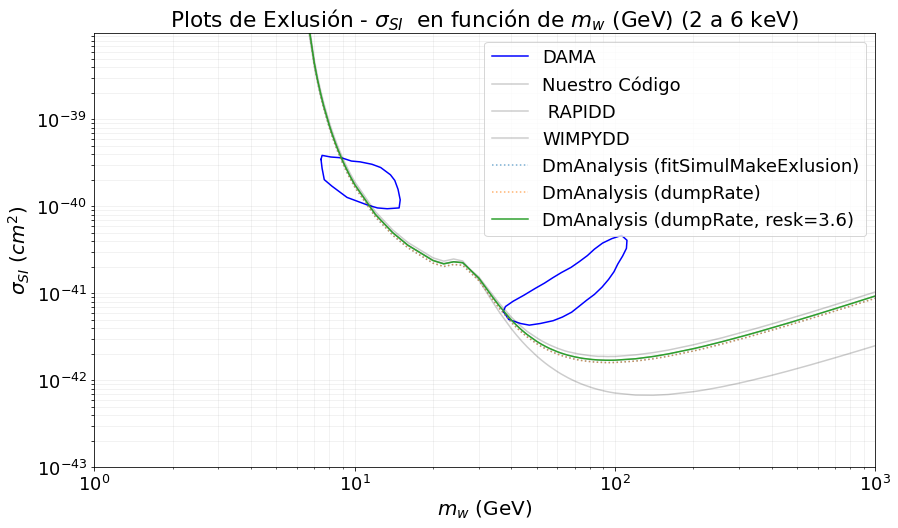

In [ ]:
plt.figure(figsize=(14, 8))
ax = plt.subplot()



'''
ax.plot(PY_M,PY, linestyle='-',label="Nuestro Código",c="black", alpha=0.8)
ax.plot(RA_M,RA,linestyle=':',label=" RAPIDD", alpha=1)
ax.plot(WI_M,WI, linestyle='--',label="WIMPYDD", alpha=1)
ax.plot(DM_2_M,DM_2, linestyle='-',label="DmAnalysis (fitSimulMakeExlusion)", alpha=0.7)
ax.plot(DM_3_M,DM_3, linestyle='-',label="DmAnalysis (dumpRate)", alpha=0.7)
'''

ax.plot(DAMA1_x,DAMA1_y,c='blue',label="DAMA")
ax.plot(DAMA2_x,DAMA2_y,c='blue')

ax.plot(PY_M,PY, linestyle='-',label="Nuestro Código",c="black", alpha=0.2)
ax.plot(RA_M,RA,linestyle='-',label=" RAPIDD",c="black", alpha=0.2)
ax.plot(WI_M,WI, linestyle='-',label="WIMPYDD",c="black", alpha=0.2)


ax.plot(DM_2_M,DM_2, linestyle=':',label="DmAnalysis (fitSimulMakeExlusion)", alpha=0.6)
ax.plot(DM_3_M,DM_3, linestyle=':',label="DmAnalysis (dumpRate)", alpha=0.6)

ax.plot(Resk_M,Resk, linestyle='-',label="DmAnalysis (dumpRate, resk=3.6)", alpha=1)



ax.legend()

ax.set_title(r'Plots de Exlusión - $\sigma_{SI}$  en función de $m_w$ (GeV) (2 a 6 keV)')
ax.set_ylabel(r'$\sigma_{SI}$ $(cm^2)$',fontsize=20)
ax.set_xlabel(r'$m_w$ (GeV)',fontsize=20)

ax.set_yscale("log")
ax.set_xscale("log")

y_sup=1e-38
y_inf=1e-43

ax.set_ylim(y_inf,y_sup)
ax.set_xlim(1,1000)

exp_min = int(np.floor(np.log10(y_inf)))   
exp_max = int(np.ceil(np.log10(y_sup)))    
exps = np.arange(exp_min, exp_max)     


all_ticks = []
for e in exps:
    decade = (np.arange(1, 10) * (10.0**e)).tolist()
    all_ticks.extend(decade)
all_ticks = np.array(all_ticks)

ax.set_yticks(all_ticks)                    

ax.grid(which='both', linestyle='-', alpha=0.2)


m=Resk_M
s=Resk

fichero = open("SI_ANAIS_INT_2_6.txt", 'w')
# Guardamos la lista en el fichero
for i in range(len(m)):
    fichero.write(f"{m[i]} \t {s[i]} \n")

# Cerramos el fichero
fichero.close()